In [ ]:
# #Libraries: Import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# #Upload: Upload data file
from google.colab import files
uploaded=files.upload()

In [ ]:
# #LoadData: Read CSV
train=pd.read_csv('train.csv')

In [ ]:
# #Explore: Display first 5 rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# #Explore: Display last 5 rows
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
# #Explore: DataFrame summary
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# #Explore: Descriptive statistics
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

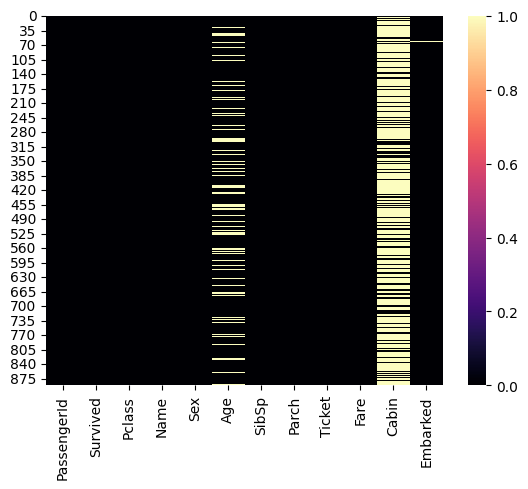

In [ ]:
# #Visualize: Missing values heatmap
sns.heatmap(train.isnull(), cmap= "magma")

In [ ]:
# #FeatureEngineering: Cabin substring func
cabin_list = [ 'A','B','C','D','E','F','T','G','Unknown']
def search_substring(big_string, substring_list):
  for substring in substring_list:
    if substring in big_string:
      return substring
      return substring_list[-1]

In [ ]:
# #Test: Regex
from IPython.core.formatters import PlainTextFormatter
import re
a= "gods plan"
b= re.search("plan", a)
print(b.group())

plan


In [ ]:
# #FeatureEngineering: Extract titles func
def get_title(string):
  regex=re.compile("Mr|Don|Major|Capt|Jonkheer|Rev|Dr|Mrs|Countess|Dona|Mme|Ms|Miss|Mlle|Master",re.IGNORECASE)
  results= regex.search(string)
  if results != None:
    return(results.group().lower())
  else:
    return(str(np.nan))

In [ ]:
# #FeatureEngineering: Title mapping dict

title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [ ]:
# #FeatureEngineering: Apply Deck & Title
train['Deck']= train['Cabin'].map(lambda x: search_substring(str(x), cabin_list))
train.drop('Cabin', axis=1, inplace=True)
train['Title']=train['Name'].apply(get_title)
train["Title"]= train['Title'].map(title_dictionary)

In [ ]:
# #Verify: Display head after changes
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,None,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,None,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,None,Mr


In [ ]:
train.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,None,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,None,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,373450,8.0500,S,None,Mr


In [ ]:

train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,None,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,None,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,None,Mr


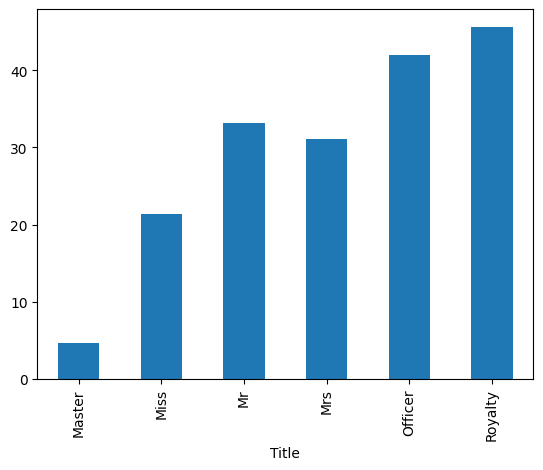

In [ ]:
# #DataCleaning: Mean age per title
means_title= train.groupby('Title')['Age'].mean()
mk= train.groupby('Title')['Age'].mean().plot(kind='bar')

In [ ]:
# #DataCleaning: Fill missing Age func
title_list=['mr','miss','master','royalty','officer']
def age_nan_replace(means, dframe, title_list):
    for title in title_list:
      temp=dframe['Title'] == title
      dframe.loc[temp,'Age']= dframe.loc[temp,'Age'].fillna(means[title])
      age_nan_replace(means_title, train, title_list)
      age_nan_replace(means_title, train, title_list)

<Axes: xlabel='Embarked'>

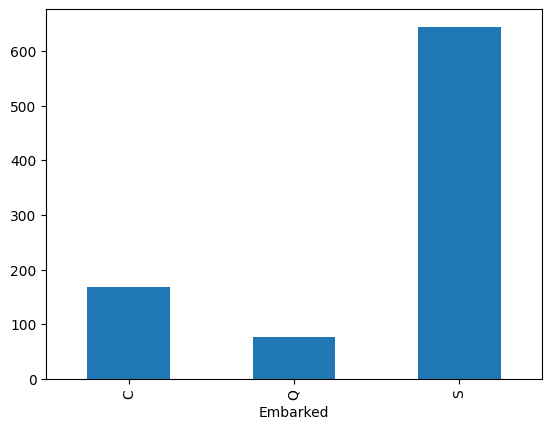

In [ ]:
# #Visualize: Embarked distribution
train.groupby('Embarked').size().plot(kind='bar')

<Axes: >

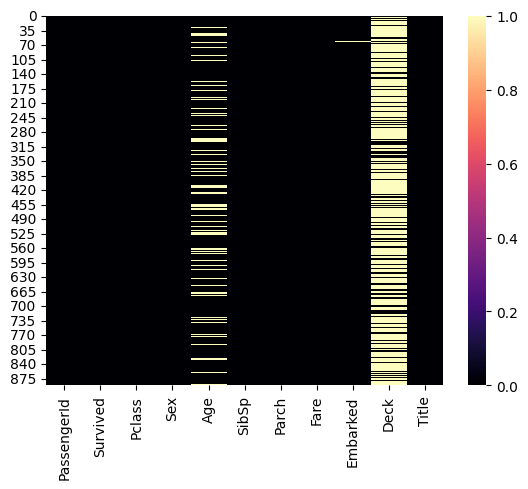

In [ ]:
# #Visualize: Re-check missing
sns.heatmap(train.isnull(),cmap='magma')

In [ ]:
# #DataCleaning: Fill Embarked
train['Embarked'].fillna('S',inplace=True)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,Title
0,1,0,3,male,22.0,1,0,7.2500,S,None,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,C,Mr
2,3,1,3,female,26.0,0,0,7.9250,S,None,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,C,Mr
4,5,0,3,male,35.0,0,0,8.0500,S,None,Mr


/tmp/ipykernel_5080/526602505.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  train.pivot_table('Survived',parch_intervals, 'Sex').plot(kind='bar')


<Axes: xlabel='Parch'>

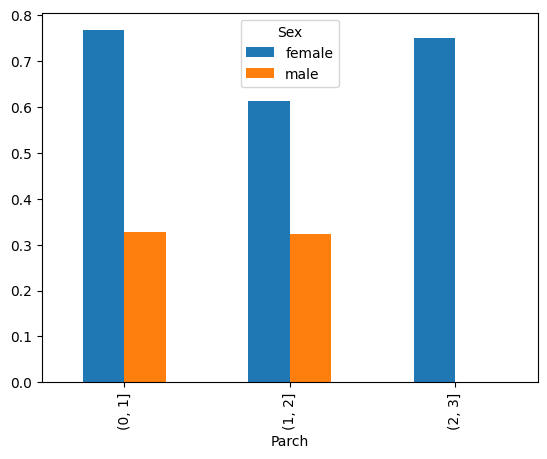

In [ ]:
# #AnalyzeSurvival: Parch & Sex survival
parch_intervals = pd.cut(train['Parch'], [0,1,2,3])
train.pivot_table('Survived',parch_intervals, 'Sex').plot(kind='bar')

/tmp/ipykernel_5080/2794534349.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  train.pivot_table('Survived',sibsp_intervals, 'Sex').plot(kind='bar')


<Axes: xlabel='SibSp'>

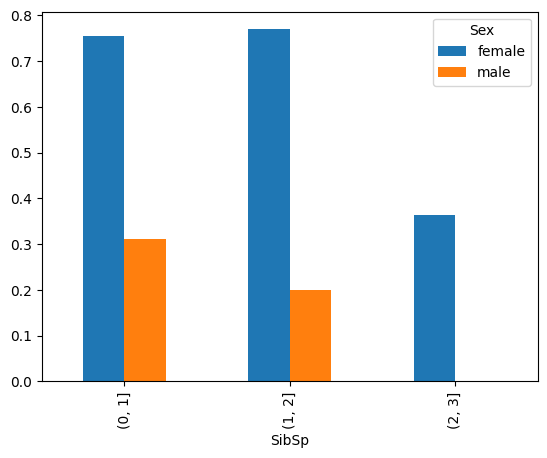

In [ ]:
# #AnalyzeSurvival: SibSp & Sex survival
sibsp_intervals = pd.cut(train['SibSp'], [0,1,2,3])
train.pivot_table('Survived',sibsp_intervals, 'Sex').plot(kind='bar')

In [ ]:
# #FeatureEngineering: Family Size & drop

if 'Parch' in train.columns and 'SibSp' in train.columns:
    train['Family Size'] = train['Parch'] + train['SibSp']
    train.drop('Parch', axis=1, inplace=True)
    train.drop('SibSp', axis=1, inplace=True)
    print("Family Size column created and 'Parch' and 'SibSp' columns dropped.")
else:
    print("Error: 'Parch' or 'SibSp' columns not found. This might be because they were already dropped in a previous execution. Please ensure the DataFrame 'train' is in the correct state by re-running the data loading cell (cell '_35Z_ULgI9p0') if you wish to re-perform these operations.")

train.head()

Error: 'Parch' or 'SibSp' columns not found. This might be because they were already dropped in a previous execution. Please ensure the DataFrame 'train' is in the correct state by re-running the data loading cell (cell '_35Z_ULgI9p0') if you wish to re-perform these operations.


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,Deck,Title,Family Size
0,1,0,3,male,22.0,1,7.2500,S,None,Mr,1
1,2,1,1,female,38.0,1,71.2833,C,C,Mr,1
2,3,1,3,female,26.0,0,7.9250,S,None,Miss,0
3,4,1,1,female,35.0,1,53.1000,S,C,Mr,1
4,5,0,3,male,35.0,0,8.0500,S,None,Mr,0
